In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn
import streamlit as st
import holidays


In [5]:
import pandas as pd

import pandas as pd

# Rutas relativas correctas
path_ventas = "../data/raw/entrenamiento/ventas.csv"
path_competencia = "../data/raw/entrenamiento/competencia.csv"

# Carga de datos
df_ventas = pd.read_csv(path_ventas)
df_competencia = pd.read_csv(path_competencia)

print("🤖 ¡Datos cargados con éxito!")
df_ventas.head()


🤖 ¡Datos cargados con éxito!


,fecha,producto_id,nombre,categoria,subcategoria,precio_base,es_estrella,unidades_vendidas,precio_venta,ingresos
0,2021-10-25,PROD_001,Nike Air Zoom Pegasus 40,Running,Zapatillas Running,115,True,6,118.36,710.16
1,2021-10-25,PROD_002,Adidas Ultraboost 23,Running,Zapatillas Running,135,True,10,136.82,1368.20
2,2021-10-25,PROD_003,Asics Gel Nimbus 25,Running,Zapatillas Running,85,False,2,84.93,169.86
3,2021-10-25,PROD_004,New Balance Fresh Foam X 1080v12,Running,Zapatillas Running,75,False,2,75.42,150.84
4,2021-10-25,PROD_005,Nike Dri-FIT Miler,Running,Ropa Running,35,False,2,35.87,71.74


In [6]:
df_ventas.head()

,fecha,producto_id,nombre,categoria,subcategoria,precio_base,es_estrella,unidades_vendidas,precio_venta,ingresos
0,2021-10-25,PROD_001,Nike Air Zoom Pegasus 40,Running,Zapatillas Running,115,True,6,118.36,710.16
1,2021-10-25,PROD_002,Adidas Ultraboost 23,Running,Zapatillas Running,135,True,10,136.82,1368.20
2,2021-10-25,PROD_003,Asics Gel Nimbus 25,Running,Zapatillas Running,85,False,2,84.93,169.86
3,2021-10-25,PROD_004,New Balance Fresh Foam X 1080v12,Running,Zapatillas Running,75,False,2,75.42,150.84
4,2021-10-25,PROD_005,Nike Dri-FIT Miler,Running,Ropa Running,35,False,2,35.87,71.74


In [7]:
df_competencia.head()

,fecha,producto_id,Amazon,Decathlon,Deporvillage
0,2021-10-25,PROD_001,82.96,111.88,97.43
1,2021-10-25,PROD_002,112.56,108.61,115.58
2,2021-10-25,PROD_003,79.79,78.44,80.11
3,2021-10-25,PROD_004,72.60,67.29,74.45
4,2021-10-25,PROD_005,37.71,33.60,33.07


In [10]:
df_ventas.columns

Index(['fecha', 'producto_id', 'nombre', 'categoria', 'subcategoria',
       'precio_base', 'es_estrella', 'unidades_vendidas', 'precio_venta',
       'ingresos'],
      dtype='object')

In [13]:
df_competencia.columns



Index(['fecha', 'producto_id', 'Amazon', 'Decathlon', 'Deporvillage'], dtype='object')

In [14]:
# 1. Información general y tipos de datos
print("--- Información General ---")
df_ventas.info()

# 2. Conteo de valores nulos
print("\n--- Valores Nulos ---")
print(df_ventas.isnull().sum())

# 3. Datos duplicados
print("\n--- Filas Duplicadas ---")
print(f"Total de duplicados: {df_ventas.duplicated().sum()}")

# 4. Estadísticos descriptivos
print("\n--- Resumen Estadístico ---")
display(df_ventas.describe(include='all'))


--- Información General ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3552 entries, 0 to 3551
Data columns (total 10 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   fecha              3552 non-null   object 
 1   producto_id        3552 non-null   object 
 2   nombre             3552 non-null   object 
 3   categoria          3552 non-null   object 
 4   subcategoria       3552 non-null   object 
 5   precio_base        3552 non-null   int64  
 6   es_estrella        3552 non-null   bool   
 7   unidades_vendidas  3552 non-null   int64  
 8   precio_venta       3552 non-null   float64
 9   ingresos           3552 non-null   float64
dtypes: bool(1), float64(2), int64(2), object(5)
memory usage: 253.3+ KB

--- Valores Nulos ---
fecha                0
producto_id          0
nombre               0
categoria            0
subcategoria         0
precio_base          0
es_estrella          0
unidades_vendidas    0
precio_ve

,fecha,producto_id,nombre,categoria,subcategoria,precio_base,es_estrella,unidades_vendidas,precio_venta,ingresos
count,3552,3552,3552,3552,3552,3552.000000,3552,3552.00000,3552.000000,3552.000000
unique,148,24,24,4,16,NaN,2,NaN,NaN,NaN
top,2021-10-25,PROD_001,Nike Air Zoom Pegasus 40,Running,Zapatillas Running,NaN,False,NaN,NaN,NaN
freq,24,148,148,1184,888,NaN,2516,NaN,NaN,NaN
mean,NaN,NaN,NaN,NaN,NaN,123.125000,NaN,4.87866,121.816546,605.972323
std,NaN,NaN,NaN,NaN,NaN,165.576753,NaN,6.31102,164.017963,1079.071192
min,NaN,NaN,NaN,NaN,NaN,20.000000,NaN,1.00000,19.000000,19.460000
25%,NaN,NaN,NaN,NaN,NaN,48.750000,NaN,2.00000,47.212500,131.535000
50%,NaN,NaN,NaN,NaN,NaN,72.500000,NaN,3.00000,71.810000,216.570000
75%,NaN,NaN,NaN,NaN,NaN,118.750000,NaN,5.00000,118.220000,639.637500


In [15]:
# 1. Información y tipos
print("--- Información df_competencia ---")
df_competencia.info()

# 2. Nulos y Duplicados
print(f"\nValores nulos:\n{df_competencia.isnull().sum()}")
print(f"\nTotal de duplicados: {df_competencia.duplicated().sum()}")

# 3. Estadísticos
display(df_competencia.describe(include='all'))


--- Información df_competencia ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3552 entries, 0 to 3551
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   fecha         3552 non-null   object 
 1   producto_id   3552 non-null   object 
 2   Amazon        3552 non-null   float64
 3   Decathlon     3552 non-null   float64
 4   Deporvillage  3552 non-null   float64
dtypes: float64(3), object(2)
memory usage: 138.9+ KB

Valores nulos:
fecha           0
producto_id     0
Amazon          0
Decathlon       0
Deporvillage    0
dtype: int64

Total de duplicados: 0


,fecha,producto_id,Amazon,Decathlon,Deporvillage
count,3552,3552,3552.000000,3552.000000,3552.000000
unique,148,24,NaN,NaN,NaN
top,2021-10-25,PROD_001,NaN,NaN,NaN
freq,24,148,NaN,NaN,NaN
mean,NaN,NaN,118.623407,111.412182,118.894628
std,NaN,NaN,156.095628,148.508132,160.216448
min,NaN,NaN,16.850000,15.450000,16.770000
25%,NaN,NaN,47.117500,43.285000,47.310000
50%,NaN,NaN,73.180000,66.285000,72.700000
75%,NaN,NaN,114.342500,111.172500,114.985000


In [25]:
# Convertimos la columna 'fecha' a formato datetime
df_ventas['fecha'] = pd.to_datetime(df_ventas['fecha'])
df_competencia['fecha'] = pd.to_datetime(df_competencia['fecha'])

# Verificamos que el cambio se ha realizado correctamente
print("🤖 ¡Conversión completada!")
print(f"Tipo de fecha en df_ventas: {df_ventas['fecha'].dtype}")
print(f"Tipo de fecha en df_competencia: {df_competencia['fecha'].dtype}")

# Mostramos las primeras filas para confirmar que visualmente todo sigue bien
df_ventas.head()



🤖 ¡Conversión completada!
Tipo de fecha en df_ventas: datetime64[ns]
Tipo de fecha en df_competencia: datetime64[ns]


,fecha,producto_id,nombre,categoria,subcategoria,precio_base,es_estrella,unidades_vendidas,precio_venta,ingresos
0,2021-10-25,PROD_001,Nike Air Zoom Pegasus 40,Running,Zapatillas Running,115,True,6,118.36,710.16
1,2021-10-25,PROD_002,Adidas Ultraboost 23,Running,Zapatillas Running,135,True,10,136.82,1368.20
2,2021-10-25,PROD_003,Asics Gel Nimbus 25,Running,Zapatillas Running,85,False,2,84.93,169.86
3,2021-10-25,PROD_004,New Balance Fresh Foam X 1080v12,Running,Zapatillas Running,75,False,2,75.42,150.84
4,2021-10-25,PROD_005,Nike Dri-FIT Miler,Running,Ropa Running,35,False,2,35.87,71.74


In [30]:
# Unimos los dos DataFrames usando 'fecha' y 'producto_id' como llaves
DF = pd.merge(df_ventas, df_competencia, on=['fecha', 'producto_id'], how='inner')

# Verificamos que la unión ha sido exitosa
print("🤖 ¡Unión completada! El nuevo DataFrame 'DF' ya está listo.")
print(f"Dimensiones finales: {DF.shape}")

# Mostramos las primeras filas para ver las nuevas columnas de competencia
DF.head()


🤖 ¡Unión completada! El nuevo DataFrame 'DF' ya está listo.
Dimensiones finales: (3552, 13)


,fecha,producto_id,nombre,categoria,subcategoria,precio_base,es_estrella,unidades_vendidas,precio_venta,ingresos,Amazon,Decathlon,Deporvillage
0,2021-10-25,PROD_001,Nike Air Zoom Pegasus 40,Running,Zapatillas Running,115,True,6,118.36,710.16,82.96,111.88,97.43
1,2021-10-25,PROD_002,Adidas Ultraboost 23,Running,Zapatillas Running,135,True,10,136.82,1368.20,112.56,108.61,115.58
2,2021-10-25,PROD_003,Asics Gel Nimbus 25,Running,Zapatillas Running,85,False,2,84.93,169.86,79.79,78.44,80.11
3,2021-10-25,PROD_004,New Balance Fresh Foam X 1080v12,Running,Zapatillas Running,75,False,2,75.42,150.84,72.60,67.29,74.45
4,2021-10-25,PROD_005,Nike Dri-FIT Miler,Running,Ropa Running,35,False,2,35.87,71.74,37.71,33.60,33.07


In [31]:
DF.head

<bound method NDFrame.head of           fecha producto_id                            nombre categoria  \
0    2021-10-25    PROD_001          Nike Air Zoom Pegasus 40   Running   
1    2021-10-25    PROD_002              Adidas Ultraboost 23   Running   
2    2021-10-25    PROD_003               Asics Gel Nimbus 25   Running   
3    2021-10-25    PROD_004  New Balance Fresh Foam X 1080v12   Running   
4    2021-10-25    PROD_005                Nike Dri-FIT Miler   Running   
...         ...         ...                               ...       ...   
3547 2024-11-30    PROD_020                     Quechua MH500   Outdoor   
3548 2024-11-30    PROD_021              Manduka PRO Yoga Mat  Wellness   
3549 2024-11-30    PROD_022          Gaiam Premium Yoga Block  Wellness   
3550 2024-11-30    PROD_023                  Liforme Yoga Pad  Wellness   
3551 2024-11-30    PROD_024          Lotuscrafts Yoga Bolster  Wellness   

            subcategoria  precio_base  es_estrella  unidades_vendidas

C:\Users\Pedro\AppData\Local\Temp\ipykernel_18856\3645364992.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=DF, x='categoria', y='ingresos', estimator=sum, ax=axes[0,1], palette='viridis')
C:\Users\Pedro\AppData\Local\Temp\ipykernel_18856\3645364992.py:25: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=DF, x='es_estrella', y='unidades_vendidas', ax=axes[1,1], palette='Set2')
C:\Users\Pedro\AppData\Local\Temp\ipykernel_18856\3645364992.py:28: UserWarning: Glyph 128201 (\N{CHART WITH DOWNWARDS TREND}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\Pedro\AppData\Local\Temp\ipykernel_18856\3645364992.py:28: UserWarning: Glyph 128176 (\N{MONEY BAG}) missing from font(s

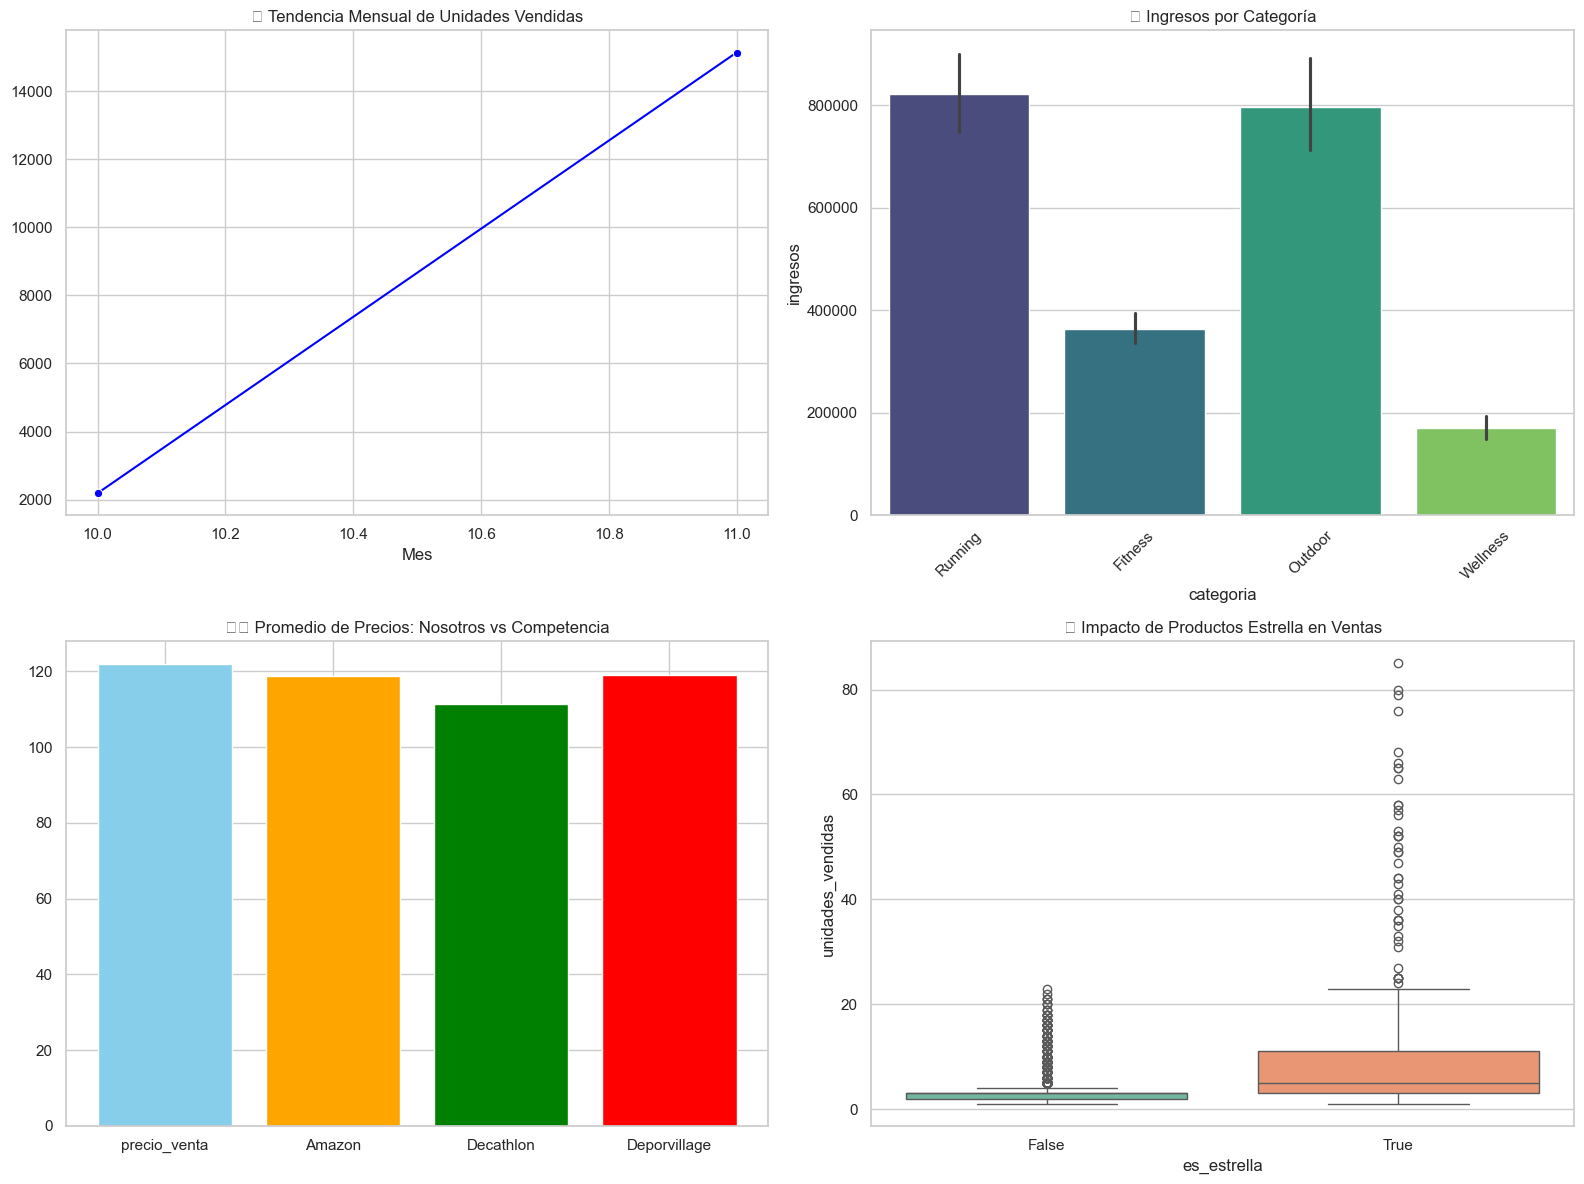

c:\Users\Pedro\miniconda3\envs\Forecasting\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 127777 (\N{THERMOMETER}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\Pedro\miniconda3\envs\Forecasting\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 65039 (\N{VARIATION SELECTOR-16}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


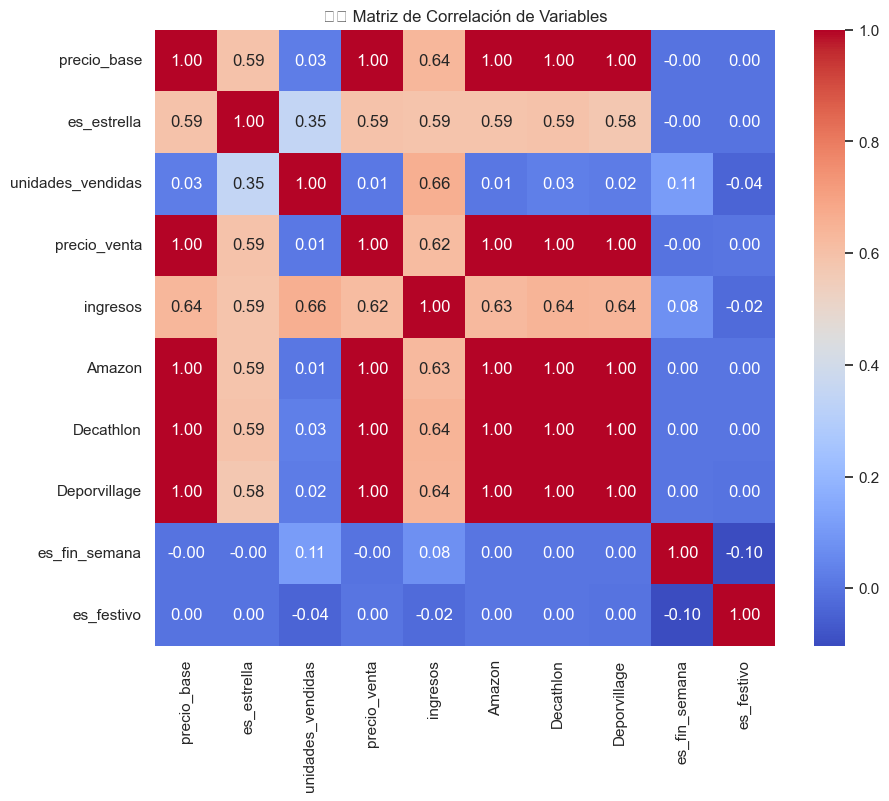

In [35]:


# Configuración de estilo
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (16, 12)

# Crear una figura con varios sub-gráficos
fig, axes = plt.subplots(2, 2)

# 1. Ventas Totales por Mes (Tendencia)
ventas_mensuales = DF.groupby('mes')['unidades_vendidas'].sum()
sns.lineplot(x=ventas_mensuales.index, y=ventas_mensuales.values, marker='o', ax=axes[0,0], color='blue')
axes[0,0].set_title('📉 Tendencia Mensual de Unidades Vendidas')
axes[0,0].set_xlabel('Mes')

# 2. Distribución de Ingresos por Categoría
sns.barplot(data=DF, x='categoria', y='ingresos', estimator=sum, ax=axes[0,1], palette='viridis')
axes[0,1].set_title('💰 Ingresos por Categoría')
axes[0,1].tick_params(axis='x', rotation=45)

# 3. Comparativa de Precios: Nosotros vs Competencia
precios_comp = DF[['precio_venta', 'Amazon', 'Decathlon', 'Deporvillage']].mean()
axes[1,0].bar(precios_comp.index, precios_comp.values, color=['skyblue', 'orange', 'green', 'red'])
axes[1,0].set_title('⚖️ Promedio de Precios: Nosotros vs Competencia')

# 4. Impacto de ser "Producto Estrella"
sns.boxplot(data=DF, x='es_estrella', y='unidades_vendidas', ax=axes[1,1], palette='Set2')
axes[1,1].set_title('⭐ Impacto de Productos Estrella en Ventas')

plt.tight_layout()
plt.show()

# 5. BONUS: Matriz de Correlación (Para ver qué afecta a los ingresos)
plt.figure(figsize=(10, 8))
# Seleccionamos solo columnas numéricas para la correlación
cols_numericas = DF.select_dtypes(include=['float64', 'int64', 'bool']).columns
sns.heatmap(DF[cols_numericas].corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title('🌡️ Matriz de Correlación de Variables')
plt.show()


In [33]:
DF.columns

Index(['fecha', 'producto_id', 'nombre', 'categoria', 'subcategoria',
       'precio_base', 'es_estrella', 'unidades_vendidas', 'precio_venta',
       'ingresos', 'Amazon', 'Decathlon', 'Deporvillage'],
      dtype='object')

In [34]:
# 1. Aseguramos que la fecha sea tipo datetime en el nuevo DF
DF['fecha'] = pd.to_datetime(DF['fecha'])

# 2. Creamos las columnas que faltaban directamente en DF
DF['mes'] = DF['fecha'].dt.month
DF['dia_semana'] = DF['fecha'].dt.dayofweek
DF['es_fin_semana'] = DF['dia_semana'].isin([5, 6])

# 3. Volvemos a añadir los festivos (por seguridad)
import holidays
festivos_espana = holidays.Spain()
DF['es_festivo'] = DF['fecha'].apply(lambda x: x in festivos_espana)

print("✅ ¡Columnas creadas! Ahora ya puedes volver a ejecutar la celda de los gráficos.")


✅ ¡Columnas creadas! Ahora ya puedes volver a ejecutar la celda de los gráficos.


C:\Users\Pedro\AppData\Local\Temp\ipykernel_18856\1098454678.py:48: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=DF, x='promo_rival', y='unidades_vendidas', palette='magma')
C:\Users\Pedro\AppData\Local\Temp\ipykernel_18856\1098454678.py:52: UserWarning: Glyph 127919 (\N{DIRECT HIT}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\Pedro\AppData\Local\Temp\ipykernel_18856\1098454678.py:52: UserWarning: Glyph 128176 (\N{MONEY BAG}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\Pedro\AppData\Local\Temp\ipykernel_18856\1098454678.py:52: UserWarning: Glyph 9876 (\N{CROSSED SWORDS}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\Pedro\AppData\Local\Temp\ipykernel_18856\1098454678.py:52: UserWarning: Glyph 65039 (\N{VARIATION SELECTOR-16}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\Pedro\App

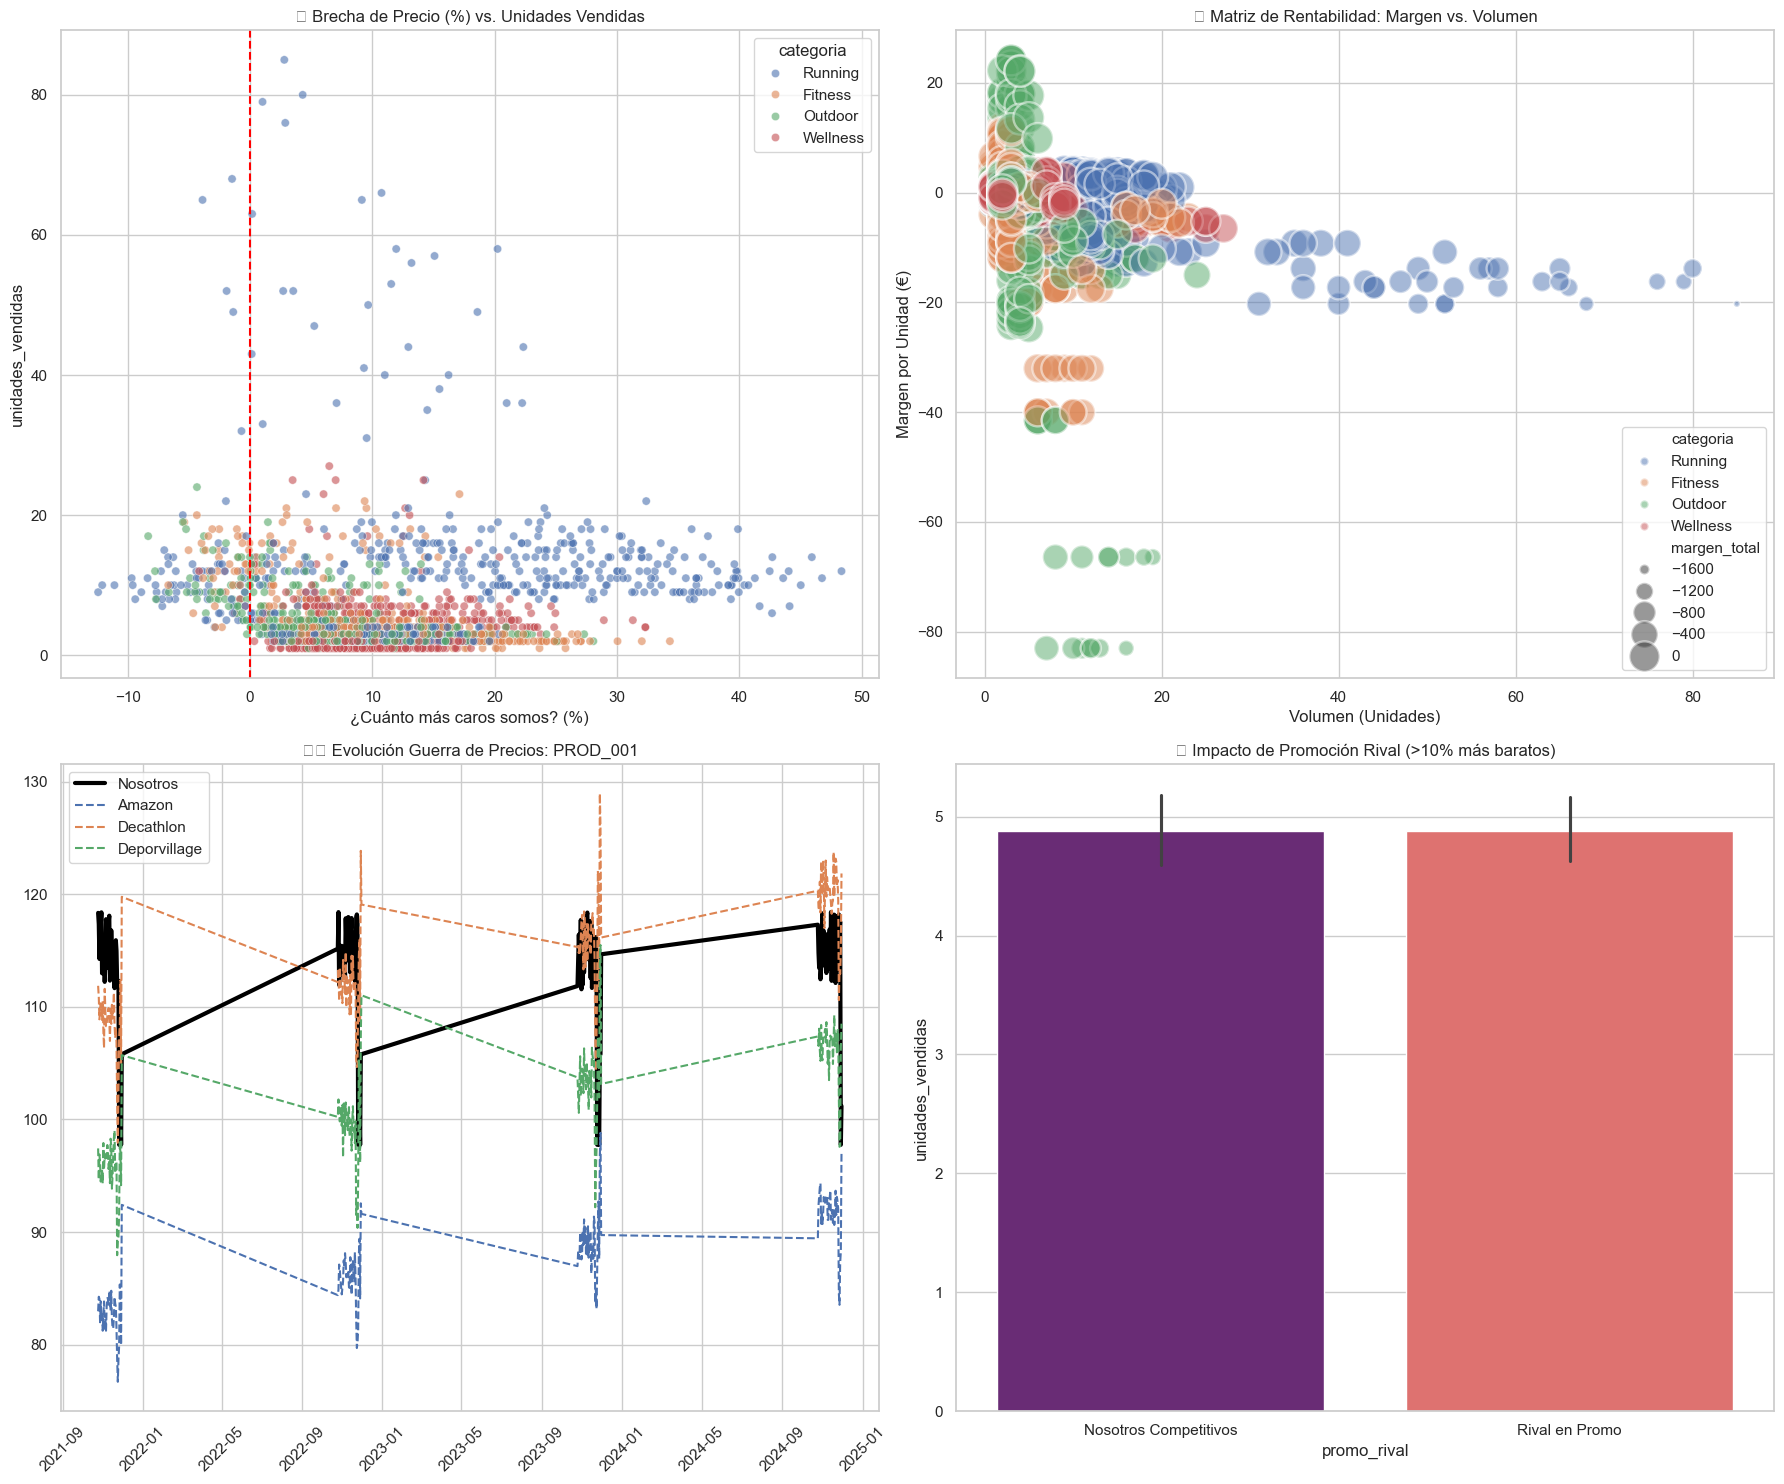

In [36]:
# --- PREPARACIÓN DE MÉTRICAS AVANZADAS ---

# 1. Calculamos el precio mínimo de la competencia por cada día/producto
DF['precio_min_competencia'] = DF[['Amazon', 'Decathlon', 'Deporvillage']].min(axis=1)

# 2. Calculamos la Brecha de Precio (Price Gap)
# Un gap positivo significa que somos más caros que el rival más barato
DF['gap_precio'] = DF['precio_venta'] - DF['precio_min_competencia']
DF['gap_porcentaje'] = (DF['gap_precio'] / DF['precio_min_competencia']) * 100

# 3. Calculamos el Margen Unitario (asumiendo precio_base como referencia de coste)
DF['margen_unitario'] = DF['precio_venta'] - DF['precio_base']
DF['margen_total'] = DF['margen_unitario'] * DF['unidades_vendidas']

# --- VISUALIZACIONES AVANZADAS ---

plt.figure(figsize=(18, 15))

# 1. Análisis de Brecha de Precio vs Unidades Vendidas
plt.subplot(2, 2, 1)
sns.scatterplot(data=DF, x='gap_porcentaje', y='unidades_vendidas', hue='categoria', alpha=0.6)
plt.axvline(0, color='red', linestyle='--') # Punto donde igualamos al competidor más barato
plt.title('🎯 Brecha de Precio (%) vs. Unidades Vendidas')
plt.xlabel('¿Cuánto más caros somos? (%)')

# 2. Matriz de Rentabilidad (Margen vs Volumen)
plt.subplot(2, 2, 2)
sns.scatterplot(data=DF, x='unidades_vendidas', y='margen_unitario', size='margen_total', hue='categoria', sizes=(20, 500), alpha=0.5)
plt.title('💰 Matriz de Rentabilidad: Margen vs. Volumen')
plt.xlabel('Volumen (Unidades)')
plt.ylabel('Margen por Unidad (€)')

# 3. Evolución de la Guerra de Precios (Ejemplo para un producto específico)
plt.subplot(2, 2, 3)
prod_ejemplo = DF['producto_id'].unique()[0] # Elegimos el primer producto para el ejemplo
df_guerra = DF[DF['producto_id'] == prod_ejemplo].sort_values('fecha')
plt.plot(df_guerra['fecha'], df_guerra['precio_venta'], label='Nosotros', linewidth=3, color='black')
plt.plot(df_guerra['fecha'], df_guerra['Amazon'], label='Amazon', linestyle='--')
plt.plot(df_guerra['fecha'], df_guerra['Decathlon'], label='Decathlon', linestyle='--')
plt.plot(df_guerra['fecha'], df_guerra['Deporvillage'], label='Deporvillage', linestyle='--')
plt.title(f'⚔️ Evolución Guerra de Precios: {prod_ejemplo}')
plt.legend()
plt.xticks(rotation=45)

# 4. Impacto de Promociones Rivales (Cuando el rival es más de un 10% más barato)
plt.subplot(2, 2, 4)
DF['promo_rival'] = DF['gap_porcentaje'] > 10
sns.barplot(data=DF, x='promo_rival', y='unidades_vendidas', palette='magma')
plt.title('🚨 Impacto de Promoción Rival (>10% más baratos)')
plt.xticks([0, 1], ['Nosotros Competitivos', 'Rival en Promo'])

plt.tight_layout()
plt.show()


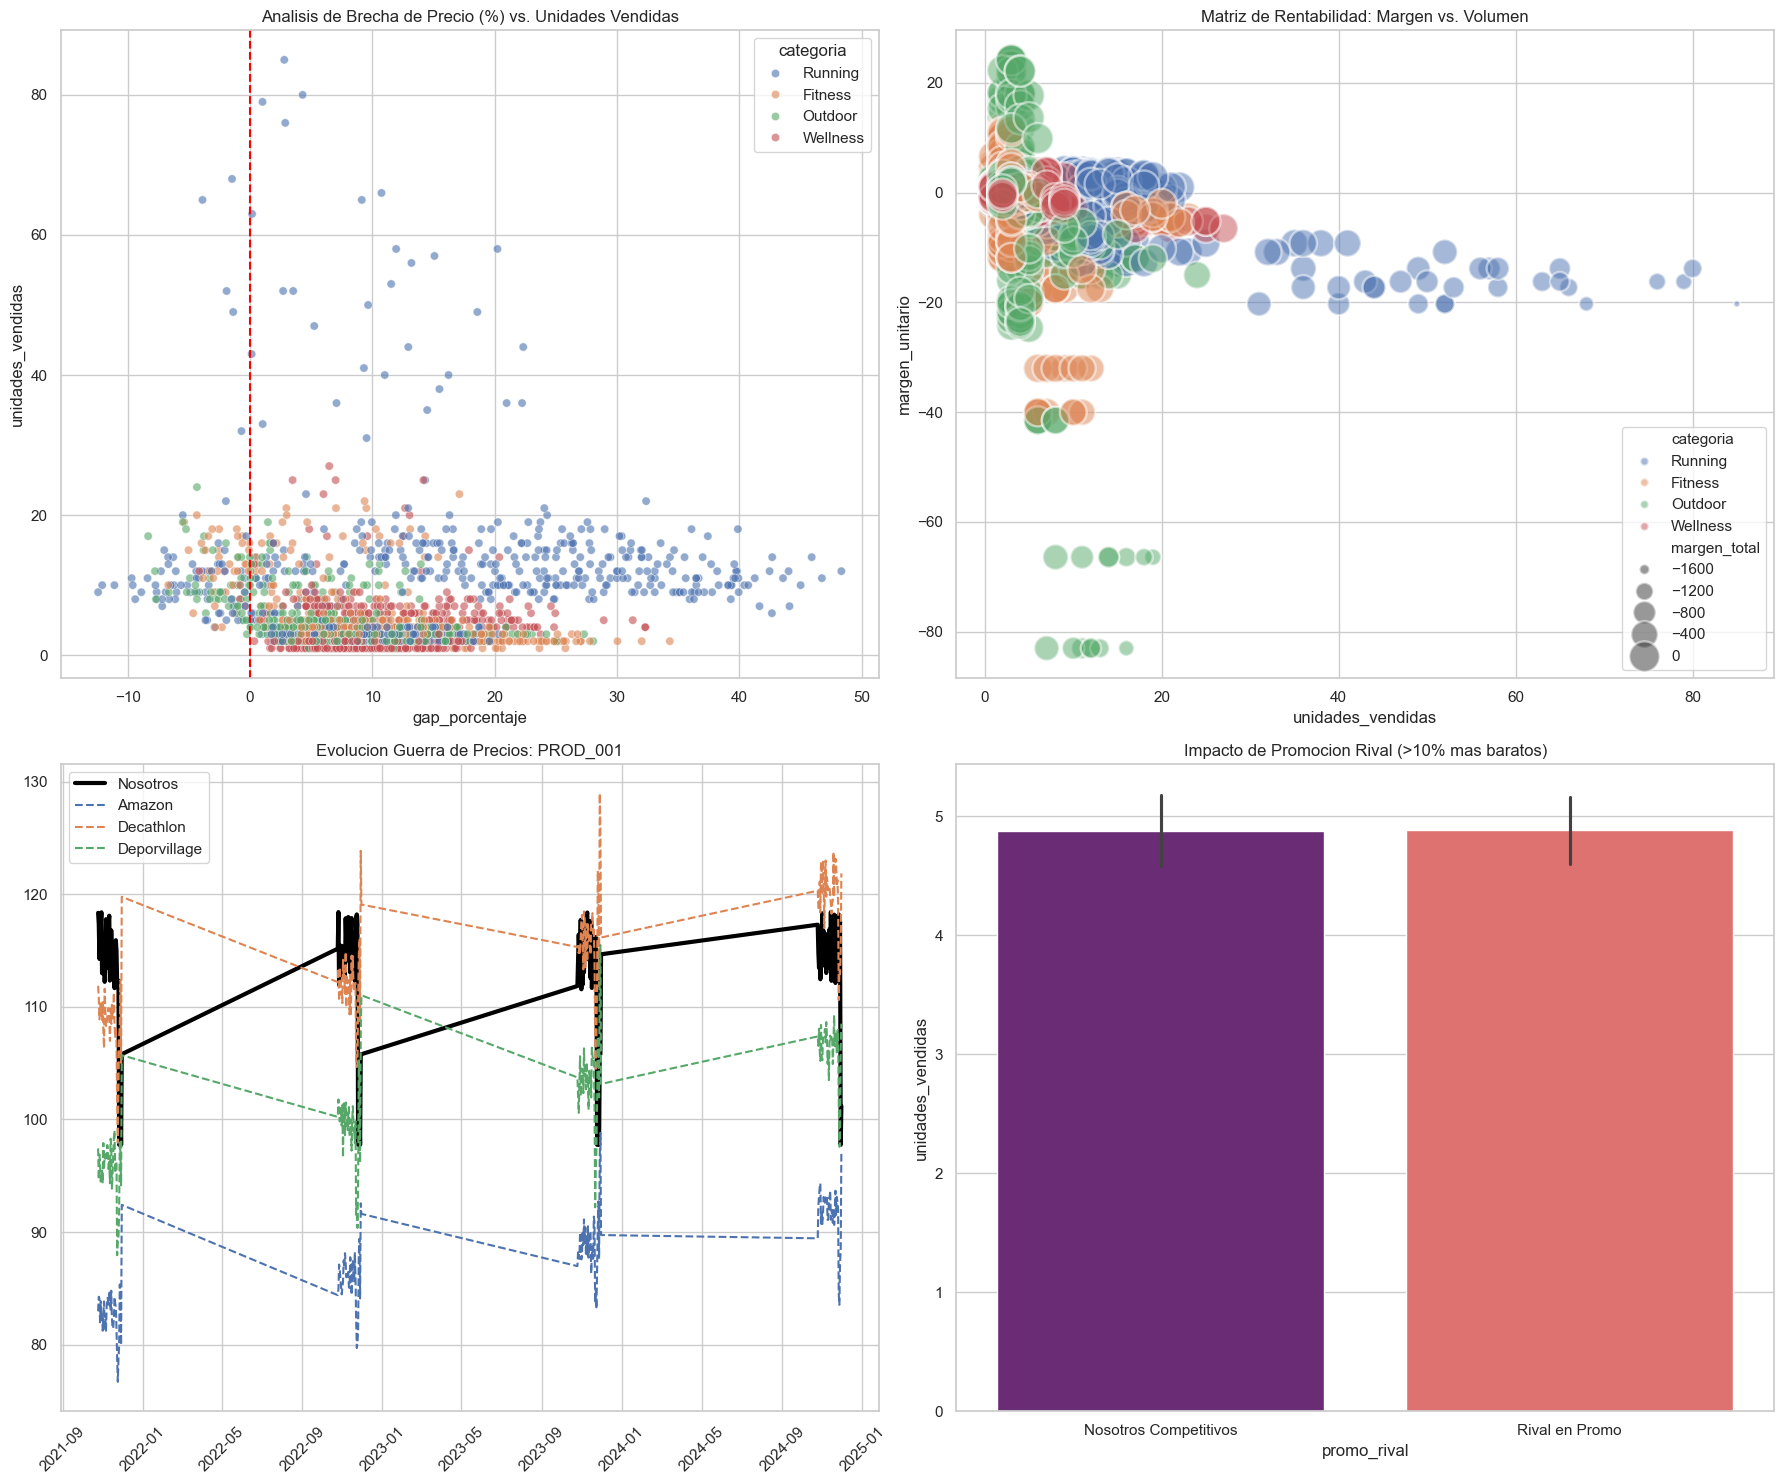

In [37]:

# 1. Ajuste para evitar el aviso de Seaborn y los emojis
plt.figure(figsize=(18, 15))

# --- GRÁFICOS AVANZADOS ---

# 1. Análisis de Brecha de Precio
plt.subplot(2, 2, 1)
sns.scatterplot(data=DF, x='gap_porcentaje', y='unidades_vendidas', hue='categoria', alpha=0.6)
plt.axvline(0, color='red', linestyle='--')
plt.title('Analisis de Brecha de Precio (%) vs. Unidades Vendidas')

# 2. Matriz de Rentabilidad
plt.subplot(2, 2, 2)
sns.scatterplot(data=DF, x='unidades_vendidas', y='margen_unitario', size='margen_total', hue='categoria', sizes=(20, 500), alpha=0.5)
plt.title('Matriz de Rentabilidad: Margen vs. Volumen')

# 3. Evolución de la Guerra de Precios
plt.subplot(2, 2, 3)
prod_ejemplo = DF['producto_id'].unique()[0]
df_guerra = DF[DF['producto_id'] == prod_ejemplo].sort_values('fecha')
plt.plot(df_guerra['fecha'], df_guerra['precio_venta'], label='Nosotros', linewidth=3, color='black')
plt.plot(df_guerra['fecha'], df_guerra['Amazon'], label='Amazon', linestyle='--')
plt.plot(df_guerra['fecha'], df_guerra['Decathlon'], label='Decathlon', linestyle='--')
plt.plot(df_guerra['fecha'], df_guerra['Deporvillage'], label='Deporvillage', linestyle='--')
plt.title(f'Evolucion Guerra de Precios: {prod_ejemplo}')
plt.legend()
plt.xticks(rotation=45)

# 4. Impacto de Promociones Rivales (Corregido con hue y sin palette sola)
plt.subplot(2, 2, 4)
DF['promo_rival'] = DF['gap_porcentaje'] > 10
# Aquí añadimos 'hue' y quitamos los emojis del título
sns.barplot(data=DF, x='promo_rival', y='unidades_vendidas', hue='promo_rival', palette='magma', legend=False)
plt.title('Impacto de Promocion Rival (>10% mas baratos)')
plt.xticks([0, 1], ['Nosotros Competitivos', 'Rival en Promo'])

plt.tight_layout()
plt.show()


🤖 ANALIZANDO PATRONES OCULTOS...

--- Sensibilidad al Precio (Correlación Gap vs Ventas) ---
categoria
Fitness    -0.461990
Outdoor    -0.492880
Running     0.134776
Wellness    0.050850
dtype: float64
💡 (Cuanto más negativo, más sensible es esa categoría al precio)


C:\Users\Pedro\AppData\Local\Temp\ipykernel_18856\3023044544.py:19: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  sensibilidad = DF.groupby('categoria').apply(lambda x: x['gap_porcentaje'].corr(x['unidades_vendidas']))


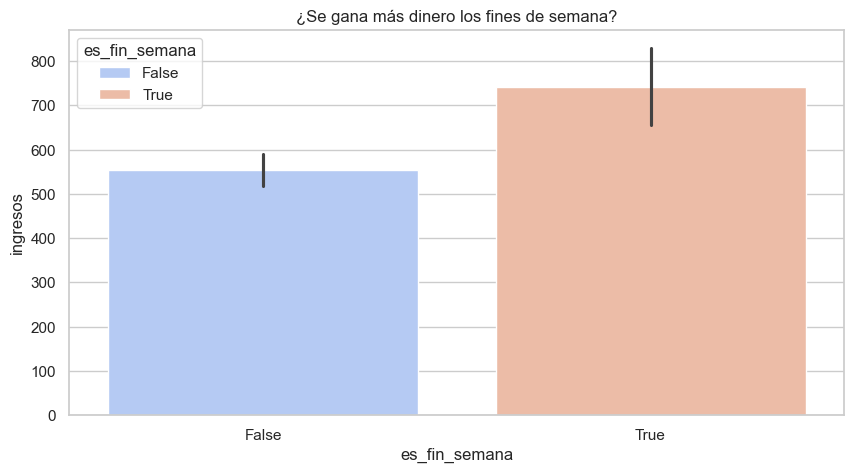


--- Rendimiento de Productos Estrella ---


,unidades_vendidas,precio_venta,margen_unitario
es_estrella,,,
False,3.470986,59.317254,-0.682746
True,8.297297,273.600541,-2.828031


In [38]:
# --- 1. CREACIÓN DE NUEVAS VARIABLES (FEATURE ENGINEERING) ---

# Ratio de competitividad (1.0 = igual que el más barato)
DF['ratio_competencia'] = DF['precio_venta'] / DF['precio_min_competencia']

# Lags (Ventas de hace 1 y 7 días) - ¡Importante para el modelo!
# Nota: Agrupamos por producto para que no mezcle ventas de distintos productos
DF = DF.sort_values(['producto_id', 'fecha'])
DF['ventas_lag1'] = DF.groupby('producto_id')['unidades_vendidas'].shift(1)
DF['ventas_lag7'] = DF.groupby('producto_id')['unidades_vendidas'].shift(7)

# --- 2. BÚSQUEDA DE PATRONES ---

print("🤖 ANALIZANDO PATRONES OCULTOS...")

# Patrón A: Sensibilidad al Precio por Categoría
# Calculamos la correlación entre el Gap y las Ventas para cada categoría
print("\n--- Sensibilidad al Precio (Correlación Gap vs Ventas) ---")
sensibilidad = DF.groupby('categoria').apply(lambda x: x['gap_porcentaje'].corr(x['unidades_vendidas']))
print(sensibilidad)
print("💡 (Cuanto más negativo, más sensible es esa categoría al precio)")

# Patrón B: El efecto del "Fin de Semana" en los ingresos
plt.figure(figsize=(10, 5))
sns.barplot(data=DF, x='es_fin_semana', y='ingresos', hue='es_fin_semana', palette='coolwarm')
plt.title('¿Se gana más dinero los fines de semana?')
plt.show()

# Patrón C: ¿Influye realmente ser estrella?
print("\n--- Rendimiento de Productos Estrella ---")
resumen_estrella = DF.groupby('es_estrella')[['unidades_vendidas', 'precio_venta', 'margen_unitario']].mean()
display(resumen_estrella)


In [40]:
import pandas as pd
import holidays
from datetime import timedelta

# Aseguramos que 'fecha' sea datetime
DF['fecha'] = pd.to_datetime(DF['fecha'])

# 1. Variables básicas de calendario
DF['dia'] = DF['fecha'].dt.day
DF['mes'] = DF['fecha'].dt.month
DF['anio'] = DF['fecha'].dt.year
DF['dia_semana'] = DF['fecha'].dt.dayofweek
DF['es_fin_semana'] = DF['dia_semana'].isin([5, 6])

# 2. Festivos oficiales (España)
festivos_espana = holidays.Spain()
DF['es_festivo'] = DF['fecha'].apply(lambda x: x in festivos_espana)

# 3. Cálculo de Black Friday y Cyber Monday
def get_special_dates(year):
    # Black Friday: 4º viernes de Noviembre
    nov = pd.date_range(start=f'{year}-11-01', end=f'{year}-11-30')
    fridays = nov[nov.weekday == 4]
    black_friday = fridays[3]
    cyber_monday = black_friday + timedelta(days=3)
    return black_friday, cyber_monday

# Aplicamos a cada año en nuestro DF
special_dates = {year: get_special_dates(year) for year in DF['anio'].unique()}

DF['es_black_friday'] = DF.apply(lambda x: x['fecha'] == special_dates[x['anio']][0], axis=1)
DF['es_cyber_monday'] = DF.apply(lambda x: x['fecha'] == special_dates[x['anio']][1], axis=1)

# 4. Variables de Comportamiento de Compra
# Quincena: Días 14, 15 y 16 (picos intermedios)
DF['es_quincena'] = DF['dia'].isin([14, 15, 16])

# Período de Cobro: Últimos 2 días y primeros 2 días del mes (cuando hay más dinero)
DF['es_cobro'] = DF['dia'].isin([30, 31, 1, 2])

# 5. Estación del Año (Muy útil para ropa/deporte)
def get_season(month):
    if month in [12, 1, 2]: return 'Invierno'
    if month in [3, 4, 5]: return 'Primavera'
    if month in [6, 7, 8]: return 'Verano'
    return 'Otono'

DF['estacion'] = DF['mes'].apply(get_season)

print("🤖 ¡Ingeniería de variables completada! Tu DF ahora es mucho más rico en información.")
# Mostramos un resumen de las nuevas columnas
DF[['fecha', 'es_black_friday', 'es_cyber_monday', 'es_quincena', 'es_cobro', 'estacion']].tail(10)


🤖 ¡Ingeniería de variables completada! Tu DF ahora es mucho más rico en información.


,fecha,es_black_friday,es_cyber_monday,es_quincena,es_cobro,estacion
3335,2024-11-21,False,False,False,False,Otono
3359,2024-11-22,True,False,False,False,Otono
3383,2024-11-23,False,False,False,False,Otono
3407,2024-11-24,False,False,False,False,Otono
3431,2024-11-25,False,True,False,False,Otono
3455,2024-11-26,False,False,False,False,Otono
3479,2024-11-27,False,False,False,False,Otono
3503,2024-11-28,False,False,False,False,Otono
3527,2024-11-29,False,False,False,False,Otono
3551,2024-11-30,False,False,False,True,Otono


In [41]:
# 1. Ordenamos por producto y fecha para que los lags se calculen correctamente
DF = DF.sort_values(by=['producto_id', 'fecha']).reset_index(drop=True)

# 2. Creamos los Lags del 1 al 7
# Agrupamos por producto y año para seguir tu instrucción de separarlos
for i in range(1, 8):
    DF[f'unidades_vendidas_lag{i}'] = DF.groupby(['producto_id', 'anio'])['unidades_vendidas'].shift(i)

# 3. Creamos la Media Móvil de 7 días (la media de la última semana)
DF['media_movil_7'] = DF.groupby(['producto_id', 'anio'])['unidades_vendidas'].transform(lambda x: x.rolling(window=7).mean())

# 4. Limpieza de Nulos
# Al crear lags y medias móviles, los primeros registros siempre son nulos (porque no tienen pasado)
total_antes = len(DF)
DF = DF.dropna().reset_index(drop=True)
total_despues = len(DF)

print(f"🤖 ¡Lags y Media Móvil creados!")
print(f"📉 Se han eliminado {total_antes - total_despues} registros iniciales que contenían nulos.")
print(f"✅ Dimensiones finales del DF: {DF.shape}")

# Mostramos cómo quedan los lags para un producto
DF[['fecha', 'producto_id', 'unidades_vendidas', 'unidades_vendidas_lag1', 'unidades_vendidas_lag7', 'media_movil_7']].head(10)


🤖 ¡Lags y Media Móvil creados!
📉 Se han eliminado 672 registros iniciales que contenían nulos.
✅ Dimensiones finales del DF: (2880, 41)


,fecha,producto_id,unidades_vendidas,unidades_vendidas_lag1,unidades_vendidas_lag7,media_movil_7
0,2021-11-01,PROD_001,7,9.0,6.0,9.000000
1,2021-11-02,PROD_001,10,7.0,8.0,9.285714
2,2021-11-03,PROD_001,11,10.0,8.0,9.714286
3,2021-11-04,PROD_001,12,11.0,7.0,10.428571
4,2021-11-05,PROD_001,10,12.0,12.0,10.142857
5,2021-11-06,PROD_001,10,10.0,12.0,9.857143
6,2021-11-07,PROD_001,10,10.0,9.0,10.000000
7,2021-11-08,PROD_001,9,10.0,7.0,10.285714
8,2021-11-09,PROD_001,11,9.0,10.0,10.428571
9,2021-11-10,PROD_001,10,11.0,11.0,10.285714


In [45]:
DF.groupby('anio').size()


anio
2021    720
2022    720
2023    720
2024    720
dtype: int64

In [46]:
# Creamos la variable descuento_porcentaje
# (Diferencia entre precio de venta y base, dividido por el base, en porcentaje)
DF['descuento_porcentaje'] = ((DF['precio_venta'] - DF['precio_base']) / DF['precio_base']) * 100

print("🤖 ¡Variable de descuento porcentual creada con éxito!")

# Veamos cómo queda para los primeros registros
display(DF[['producto_id', 'precio_base', 'precio_venta', 'descuento_porcentaje']].head())


🤖 ¡Variable de descuento porcentual creada con éxito!


,producto_id,precio_base,precio_venta,descuento_porcentaje
0,PROD_001,115,115.07,0.060870
1,PROD_001,115,116.10,0.956522
2,PROD_001,115,114.58,-0.365217
3,PROD_001,115,112.23,-2.408696
4,PROD_001,115,113.81,-1.034783


In [47]:
# 1. Creamos la variable 'prec_competencia' con el promedio de los rivales
DF['prec_competencia'] = DF[['Amazon', 'Decathlon', 'Deporvillage']].mean(axis=1)

# 2. Creamos la variable 'ratio_precio' (Nuestro precio / Promedio competencia)
# Si es 1.0, estamos exactamente en la media. < 1.0 es que somos más baratos.
DF['ratio_precio'] = DF['precio_venta'] / DF['prec_competencia']

# 3. Eliminamos las columnas individuales para limpiar el DataFrame
DF = DF.drop(columns=['Amazon', 'Decathlon', 'Deporvillage'])

print("🤖 ¡Competencia consolidada! Hemos pasado de 3 columnas a 2 métricas clave.")
display(DF[['fecha', 'producto_id', 'precio_venta', 'prec_competencia', 'ratio_precio']].head())


🤖 ¡Competencia consolidada! Hemos pasado de 3 columnas a 2 métricas clave.


,fecha,producto_id,precio_venta,prec_competencia,ratio_precio
0,2021-11-01,PROD_001,115.07,95.353333,1.206775
1,2021-11-02,PROD_001,116.10,96.153333,1.207446
2,2021-11-03,PROD_001,114.58,95.240000,1.203066
3,2021-11-04,PROD_001,112.23,96.590000,1.161922
4,2021-11-05,PROD_001,113.81,96.170000,1.183425


In [48]:
# 1. Creamos las copias con el sufijo '_h'
DF['nombre_h'] = DF['nombre']
DF['categoria_h'] = DF['categoria']
DF['subcategoria_h'] = DF['subcategoria']

# 2. Aplicamos One-Hot Encoding sobre esas copias
# Esto creará una columna nueva por cada opción (ej: categoria_h_Running, categoria_h_Fitness...)
DF = pd.get_dummies(DF, columns=['nombre_h', 'categoria_h', 'subcategoria_h'], 
                   prefix=['nombre_h', 'categoria_h', 'subcategoria_h'])

print("🤖 ¡Codificación completada!")
print(f"Ahora tu DF tiene {DF.shape[1]} columnas.")

# Mostramos un vistazo de las nuevas columnas creadas (las que terminan en _h_...)
columnas_h = [col for col in DF.columns if '_h_' in col]
DF[columnas_h].head()


🤖 ¡Codificación completada!
Ahora tu DF tiene 85 columnas.


,nombre_h_Adidas Own The Run Jacket,nombre_h_Adidas Ultraboost 23,nombre_h_Asics Gel Nimbus 25,nombre_h_Bowflex SelectTech 552,nombre_h_Columbia Silver Ridge,nombre_h_Decathlon Bandas Elásticas Set,nombre_h_Domyos BM900,nombre_h_Domyos Kit Mancuernas 20kg,nombre_h_Gaiam Premium Yoga Block,nombre_h_Liforme Yoga Pad,...,subcategoria_h_Esterilla Yoga,subcategoria_h_Mancuernas Ajustables,subcategoria_h_Mochila Trekking,subcategoria_h_Pesa Rusa,subcategoria_h_Pesas Casa,subcategoria_h_Rodillera Yoga,subcategoria_h_Ropa Montaña,subcategoria_h_Ropa Running,subcategoria_h_Zapatillas Running,subcategoria_h_Zapatillas Trail
0,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,True,False
1,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,True,False
2,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,True,False
3,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,True,False
4,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,True,False


In [49]:
DF.head()


,fecha,producto_id,nombre,categoria,subcategoria,precio_base,es_estrella,unidades_vendidas,precio_venta,ingresos,...,subcategoria_h_Esterilla Yoga,subcategoria_h_Mancuernas Ajustables,subcategoria_h_Mochila Trekking,subcategoria_h_Pesa Rusa,subcategoria_h_Pesas Casa,subcategoria_h_Rodillera Yoga,subcategoria_h_Ropa Montaña,subcategoria_h_Ropa Running,subcategoria_h_Zapatillas Running,subcategoria_h_Zapatillas Trail
0,2021-11-01,PROD_001,Nike Air Zoom Pegasus 40,Running,Zapatillas Running,115,True,7,115.07,805.49,...,False,False,False,False,False,False,False,False,True,False
1,2021-11-02,PROD_001,Nike Air Zoom Pegasus 40,Running,Zapatillas Running,115,True,10,116.10,1161.00,...,False,False,False,False,False,False,False,False,True,False
2,2021-11-03,PROD_001,Nike Air Zoom Pegasus 40,Running,Zapatillas Running,115,True,11,114.58,1260.38,...,False,False,False,False,False,False,False,False,True,False
3,2021-11-04,PROD_001,Nike Air Zoom Pegasus 40,Running,Zapatillas Running,115,True,12,112.23,1346.76,...,False,False,False,False,False,False,False,False,True,False
4,2021-11-05,PROD_001,Nike Air Zoom Pegasus 40,Running,Zapatillas Running,115,True,10,113.81,1138.10,...,False,False,False,False,False,False,False,False,True,False


In [50]:
# 1. Ver qué productos distintos hay y cuántos registros tiene cada uno
print("🤖 Lista de productos y cantidad de datos:")
print(DF['producto_id'].value_counts())

# 2. Ver una muestra aleatoria (así verás productos mezclados)
print("\n🤖 Muestra aleatoria de 10 filas:")
display(DF.sample(10))


🤖 Lista de productos y cantidad de datos:
producto_id
PROD_001    120
PROD_002    120
PROD_003    120
PROD_004    120
PROD_005    120
PROD_006    120
PROD_007    120
PROD_008    120
PROD_009    120
PROD_010    120
PROD_011    120
PROD_012    120
PROD_013    120
PROD_014    120
PROD_015    120
PROD_016    120
PROD_017    120
PROD_018    120
PROD_019    120
PROD_020    120
PROD_021    120
PROD_022    120
PROD_023    120
PROD_024    120
Name: count, dtype: int64

🤖 Muestra aleatoria de 10 filas:


,fecha,producto_id,nombre,categoria,subcategoria,precio_base,es_estrella,unidades_vendidas,precio_venta,ingresos,...,subcategoria_h_Esterilla Yoga,subcategoria_h_Mancuernas Ajustables,subcategoria_h_Mochila Trekking,subcategoria_h_Pesa Rusa,subcategoria_h_Pesas Casa,subcategoria_h_Rodillera Yoga,subcategoria_h_Ropa Montaña,subcategoria_h_Ropa Running,subcategoria_h_Zapatillas Running,subcategoria_h_Zapatillas Trail
1930,2021-11-11,PROD_017,The North Face Borealis,Outdoor,Mochila Trekking,95,False,2,97.81,195.62,...,False,False,True,False,False,False,False,False,False,False
1373,2022-11-24,PROD_012,Domyos Kit Mancuernas 20kg,Fitness,Pesas Casa,55,False,6,53.72,322.32,...,False,False,False,False,True,False,False,False,False,False
726,2021-11-07,PROD_007,Puma Velocity Nitro 2,Running,Zapatillas Running,70,False,2,71.08,142.16,...,False,False,False,False,False,False,False,False,True,False
1779,2024-11-10,PROD_015,Salomon Speedcross 5 GTX,Outdoor,Zapatillas Trail,150,True,6,150.27,901.62,...,False,False,False,False,False,False,False,False,False,True
417,2022-11-28,PROD_004,New Balance Fresh Foam X 1080v12,Running,Zapatillas Running,75,False,13,63.75,828.75,...,False,False,False,False,False,False,False,False,True,False
2260,2024-11-11,PROD_019,Merrell Moab 2 GTX,Outdoor,Zapatillas Trail,110,False,2,111.31,222.62,...,False,False,False,False,False,False,False,False,False,True
1007,2022-11-18,PROD_009,Bowflex SelectTech 552,Fitness,Mancuernas Ajustables,400,True,3,388.31,1164.93,...,False,True,False,False,False,False,False,False,False,False
592,2024-11-23,PROD_005,Nike Dri-FIT Miler,Running,Ropa Running,35,False,5,34.01,170.05,...,False,False,False,False,False,False,False,True,False,False
1780,2024-11-11,PROD_015,Salomon Speedcross 5 GTX,Outdoor,Zapatillas Trail,150,True,4,152.33,609.32,...,False,False,False,False,False,False,False,False,False,True
840,2021-11-01,PROD_008,Reebok Floatride Energy 5,Running,Zapatillas Running,65,False,2,63.09,126.18,...,False,False,False,False,False,False,False,False,True,False


In [52]:
# Definimos la ruta de guardado (subimos un nivel desde notebooks para ir a data)
path_final = "../data/processed/DF.csv"

# Guardamos el DataFrame en formato CSV
# Usamos index=False para que no se guarde una columna extra con los números de fila
DF.to_csv(path_final, index=False)

print(f"🤖 ¡Archivo guardado con éxito en: {path_final}!")
print(f"📊 Se han guardado {DF.shape[0]} filas y {DF.shape[1]} columnas listas para el modelo.")


🤖 ¡Archivo guardado con éxito en: ../data/processed/DF.csv!
📊 Se han guardado 2880 filas y 85 columnas listas para el modelo.


In [54]:
from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# 1. Preparación de variables (Predictoras y Target)
# Eliminamos fecha, ingresos y cualquier columna de texto (object)
cols_a_excluir = ['fecha', 'ingresos', 'unidades_vendidas']
predictoras = [col for col in DF.columns if col not in cols_a_excluir and DF[col].dtype != 'object']
target = 'unidades_vendidas'

X = DF[predictoras]
y = DF[target]

# 2. División Temporal (Split)
# Usamos los últimos 6 meses para validación
fecha_corte = DF['fecha'].max() - pd.DateOffset(months=6)

train_df = DF[DF['fecha'] <= fecha_corte]
val_df = DF[DF['fecha'] > fecha_corte]

X_train, y_train = train_df[predictoras], train_df[target]
X_val, y_val = val_df[predictoras], val_df[target]

print(f"🤖 Datos listos: Entrenamiento ({len(X_train)} filas) | Validación ({len(X_val)} filas)")

# 3. Entrenamiento del Modelo (Parámetros Conservadores)
model = HistGradientBoostingRegressor(
    learning_rate=0.01,
    max_iter=1000,
    max_depth=5,
    l2_regularization=0.1,
    random_state=42
)

model.fit(X_train, y_train)

# 4. Predicciones y Baseline
preds = model.predict(X_val)
baseline_preds = np.full(len(y_val), y_train.mean()) # Predice siempre la media del pasado

# 5. Evaluación de Métricas
def calcular_metricas(reales, predichas):
    mae = mean_absolute_error(reales, predichas)
    rmse = np.sqrt(mean_squared_error(reales, predichas))
    r2 = r2_score(reales, predichas)
    mape = np.mean(np.abs((reales - predichas) / reales)) * 100
    return mae, rmse, r2, mape

mae_mod, rmse_mod, r2_mod, mape_mod = calcular_metricas(y_val, preds)
mae_base, rmse_base, r2_base, mape_base = calcular_metricas(y_val, baseline_preds)

# --- INFORME DE RESULTADOS ---
print("\n" + "="*40)
print("📊 INFORME DE RENDIMIENTO DEL MODELO")
print("="*40)
print(f"{'Métrica':<15} | {'Tu Modelo':<10} | {'Baseline':<10}")
print("-" * 40)
print(f"{'MAE (Error)':<15} | {mae_mod:<10.2f} | {mae_base:<10.2f}")
print(f"{'RMSE':<15} | {rmse_mod:<10.2f} | {rmse_base:<10.2f}")
print(f"{'R2 Score':<15} | {r2_mod:<10.2f} | {r2_base:<10.2f}")
print(f"{'MAPE %':<15} | {mape_mod:<10.2f}% | {mape_base:<10.2f}%")
print("="*40)

if mae_mod < mae_base:
    print("✅ ¡Enhorabuena! Tu modelo es más inteligente que la media.")
else:
    print("⚠️ El modelo no está batiendo al baseline. Necesitamos más variables.")


🤖 Datos listos: Entrenamiento (2160 filas) | Validación (720 filas)

📊 INFORME DE RENDIMIENTO DEL MODELO
Métrica         | Tu Modelo  | Baseline  
----------------------------------------
MAE (Error)     | 0.95       | 3.67      
RMSE            | 1.81       | 6.69      
R2 Score        | 0.93       | -0.00     
MAPE %          | 19.77     % | 93.02     %
✅ ¡Enhorabuena! Tu modelo es más inteligente que la media.


✅ Gráfico generado para Nike Air Zoom Pegasus 40. Error medio en Nov: 3.00 unidades.
✅ Gráfico generado para Adidas Ultraboost 23. Error medio en Nov: 2.87 unidades.
✅ Gráfico generado para Bowflex SelectTech 552. Error medio en Nov: 0.66 unidades.
✅ Gráfico generado para Domyos BM900. Error medio en Nov: 0.52 unidades.
✅ Gráfico generado para Salomon Speedcross 5 GTX. Error medio en Nov: 1.35 unidades.
✅ Gráfico generado para Trek Marlin 7. Error medio en Nov: 0.79 unidades.
✅ Gráfico generado para Manduka PRO Yoga Mat. Error medio en Nov: 1.76 unidades.


C:\Users\Pedro\AppData\Local\Temp\ipykernel_18856\761832501.py:37: UserWarning: Glyph 127775 (\N{GLOWING STAR}) missing from font(s) Arial.
  plt.tight_layout()
c:\Users\Pedro\miniconda3\envs\Forecasting\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 127775 (\N{GLOWING STAR}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


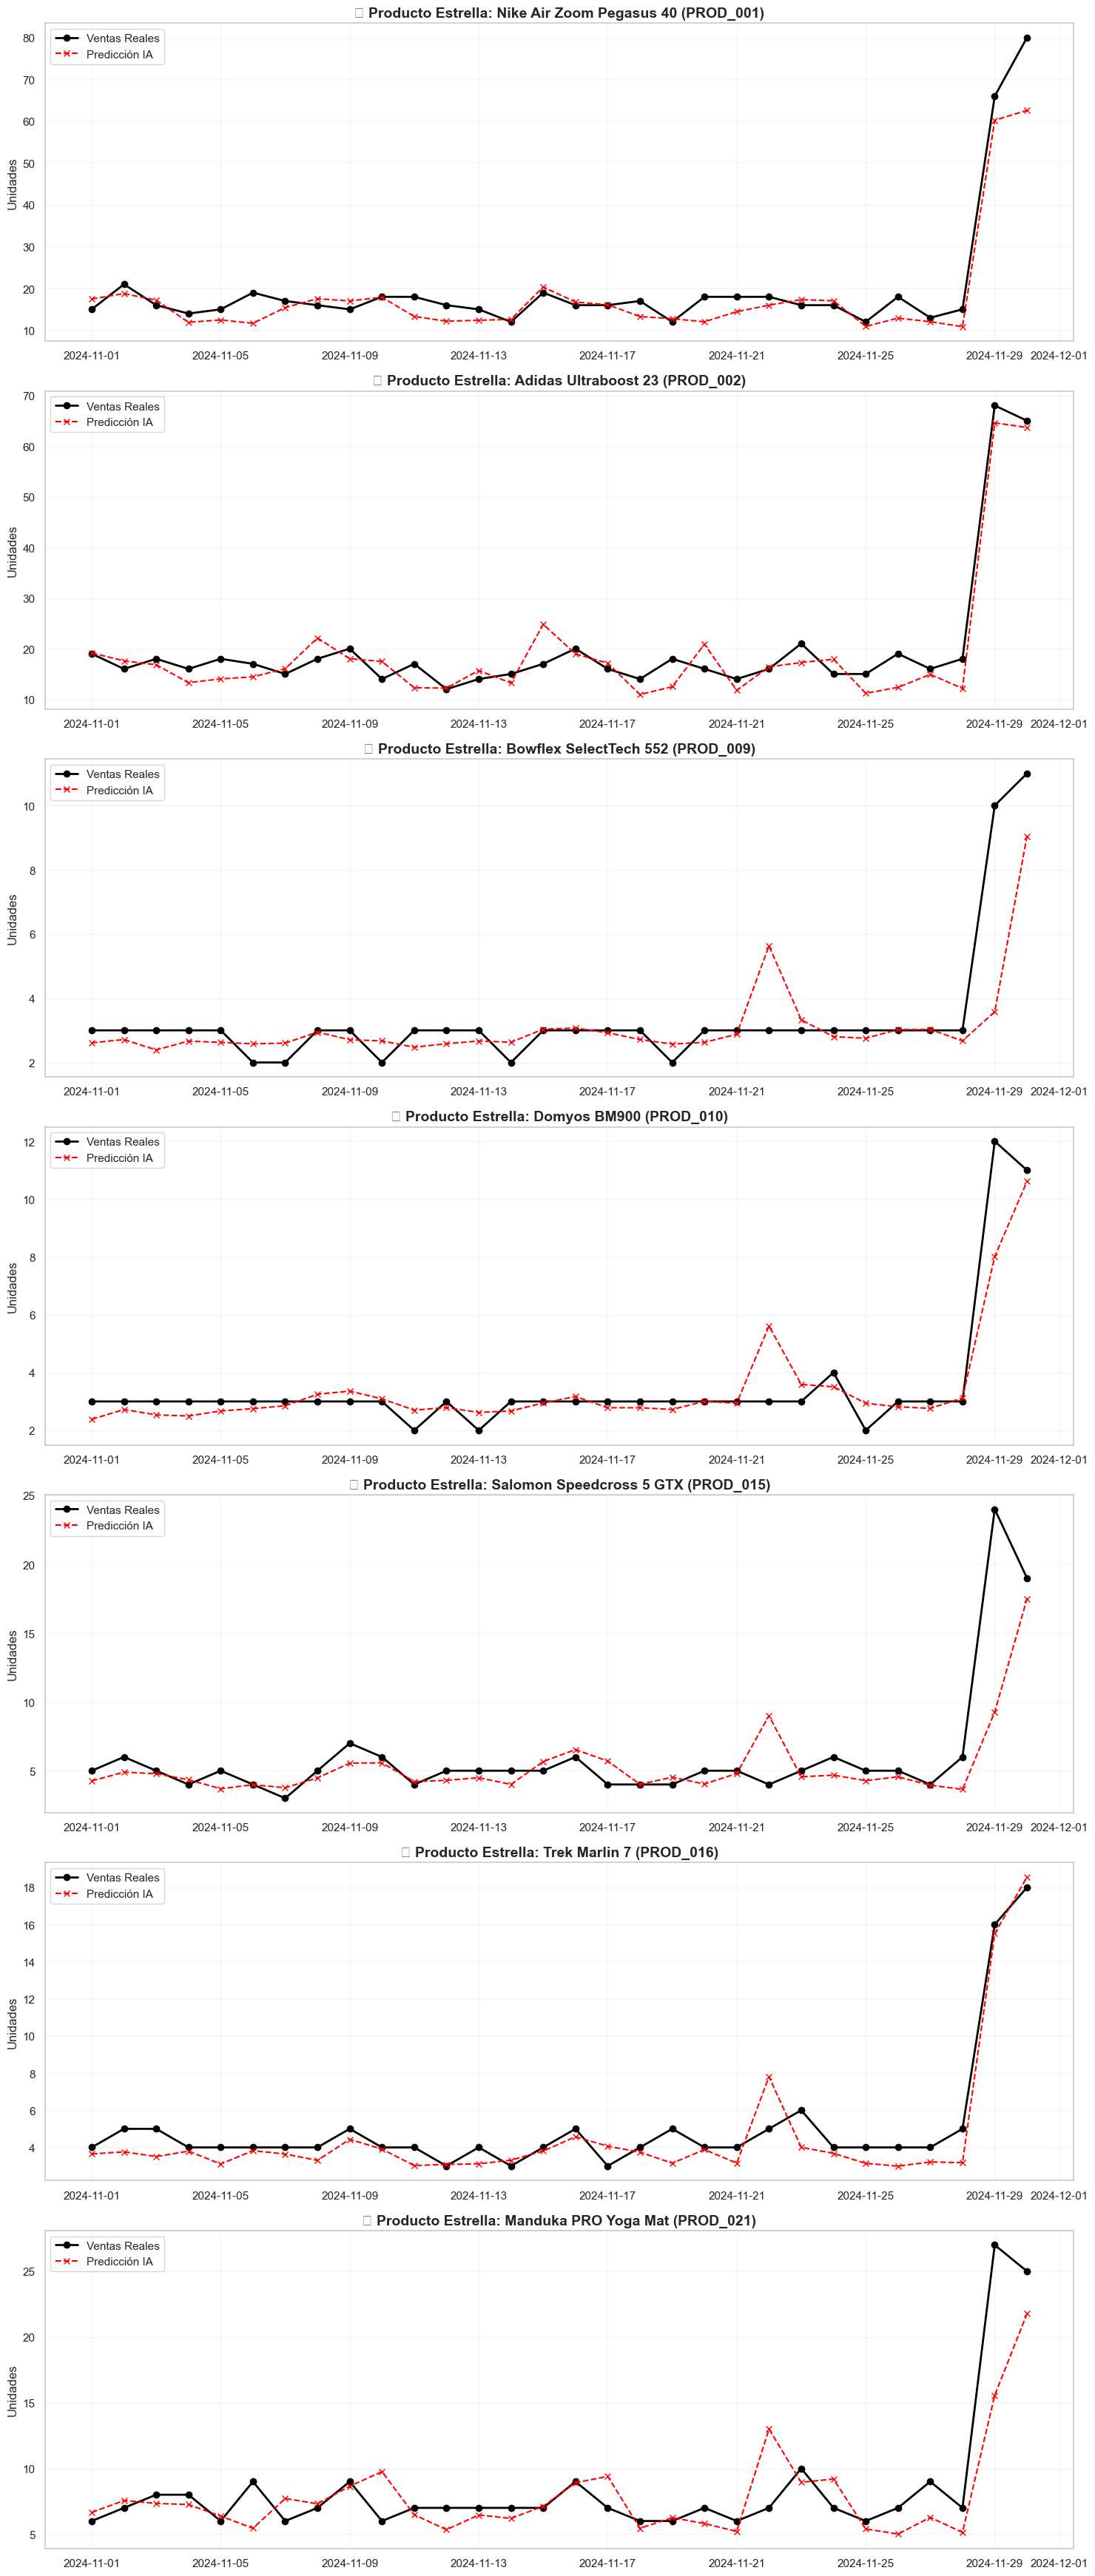

In [55]:
# 1. Filtramos los datos de Noviembre 2024 para productos estrella
nov_df = DF[(DF['fecha'].dt.month == 11) & (DF['fecha'].dt.year == 2024) & (DF['es_estrella'] == True)]

# 2. Obtenemos la lista de los productos estrella (limitamos a 7 como pediste)
productos_estrella = nov_df['producto_id'].unique()[:7]

# 3. Configuramos la visualización (7 gráficos en vertical)
fig, axes = plt.subplots(len(productos_estrella), 1, figsize=(15, 5 * len(productos_estrella)))

for i, prod_id in enumerate(productos_estrella):
    # Filtramos datos del producto
    df_p = nov_df[nov_df['producto_id'] == prod_id].sort_values('fecha')
    nombre_prod = df_p['nombre'].iloc[0]
    
    # Preparamos las predictoras para este producto
    X_p = df_p[predictoras]
    y_real = df_p[target]
    
    # Generamos predicciones
    y_pred = model.predict(X_p)
    
    # Dibujamos en su respectivo eje
    ax = axes[i] if len(productos_estrella) > 1 else axes
    ax.plot(df_p['fecha'], y_real, label='Ventas Reales', color='black', linewidth=2, marker='o')
    ax.plot(df_p['fecha'], y_pred, label='Predicción IA', color='red', linestyle='--', marker='x')
    
    # Detalles del gráfico
    ax.set_title(f'🌟 Producto Estrella: {nombre_prod} ({prod_id})', fontsize=14, fontweight='bold')
    ax.set_ylabel('Unidades')
    ax.legend()
    ax.grid(True, alpha=0.2)
    
    # Cálculo de error puntual
    mae_p = mean_absolute_error(y_real, y_pred)
    print(f"✅ Gráfico generado para {nombre_prod}. Error medio en Nov: {mae_p:.2f} unidades.")

plt.tight_layout()
plt.show()


In [56]:
# 1. Preparamos una lista para guardar los resultados
resultados_mae = []

# 2. Iteramos por los productos estrella que analizamos antes
for prod_id in productos_estrella:
    # Filtramos datos
    df_p = nov_df[nov_df['producto_id'] == prod_id]
    nombre_p = df_p['nombre'].iloc[0]
    
    # Predicciones
    y_real = df_p[target]
    y_pred = model.predict(df_p[predictoras])
    
    # Cálculo de MAE
    mae_p = mean_absolute_error(y_real, y_pred)
    
    # Guardamos en la lista
    resultados_mae.append({
        'Producto ID': prod_id,
        'Nombre': nombre_p,
        'MAE (Error medio)': round(mae_p, 2)
    })

# 3. Creamos un DataFrame resumen y lo mostramos ordenado por error
df_resumen_mae = pd.DataFrame(resultados_mae).sort_values('MAE (Error medio)')

print("📊 RESUMEN DE ERROR (MAE) POR PRODUCTO ESTRELLA - NOV 2024")
print("="*60)
display(df_resumen_mae)
print("="*60)
print("💡 Un MAE más bajo significa que el modelo es más preciso para ese producto.")


📊 RESUMEN DE ERROR (MAE) POR PRODUCTO ESTRELLA - NOV 2024


,Producto ID,Nombre,MAE (Error medio)
3,PROD_010,Domyos BM900,0.52
2,PROD_009,Bowflex SelectTech 552,0.66
5,PROD_016,Trek Marlin 7,0.79
4,PROD_015,Salomon Speedcross 5 GTX,1.35
6,PROD_021,Manduka PRO Yoga Mat,1.76
1,PROD_002,Adidas Ultraboost 23,2.87
0,PROD_001,Nike Air Zoom Pegasus 40,3.00


💡 Un MAE más bajo significa que el modelo es más preciso para ese producto.


C:\Users\Pedro\AppData\Local\Temp\ipykernel_18856\1522389239.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  nov_df['periodo'] = nov_df['fecha'].dt.day.apply(asignar_periodo)
c:\Users\Pedro\miniconda3\envs\Forecasting\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128201 (\N{CHART WITH DOWNWARDS TREND}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


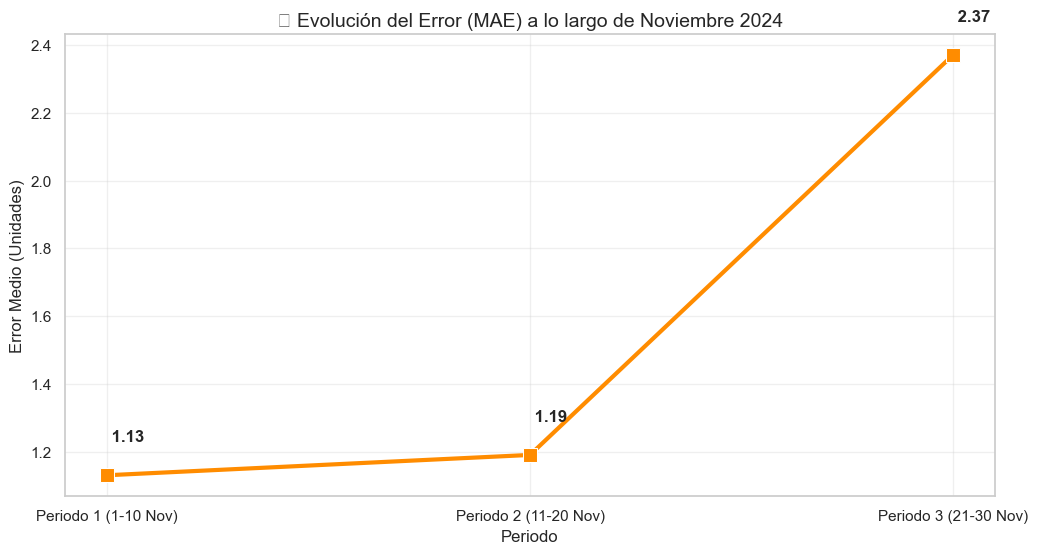

📊 RESUMEN POR PERIODOS:


,Periodo,MAE
0,Periodo 1 (1-10 Nov),1.13
1,Periodo 2 (11-20 Nov),1.19
2,Periodo 3 (21-30 Nov),2.37


In [58]:
# 1. Definimos los periodos de 10 días para noviembre 2024
def asignar_periodo(dia):
    if dia <= 10: return 'Periodo 1 (1-10 Nov)'
    if dia <= 20: return 'Periodo 2 (11-20 Nov)'
    return 'Periodo 3 (21-30 Nov)'

# 2. Aplicamos la división al DataFrame de Noviembre
nov_df['periodo'] = nov_df['fecha'].dt.day.apply(asignar_periodo)

# 3. Calculamos el MAE por periodo (para todos los productos del mes)
metricas_per = []
for periodo in sorted(nov_df['periodo'].unique()):
    df_per = nov_df[nov_df['periodo'] == periodo]
    
    # Predicciones para este periodo
    y_real = df_per[target]
    y_pred = model.predict(df_per[predictoras])
    
    # Cálculo de métricas
    mae = mean_absolute_error(y_real, y_pred)
    metricas_per.append({'Periodo': periodo, 'MAE': round(mae, 2)})

# 4. Creamos DataFrame de resultados y graficamos
df_drift = pd.DataFrame(metricas_per)

plt.figure(figsize=(12, 6))
sns.lineplot(data=df_drift, x='Periodo', y='MAE', marker='s', markersize=10, linewidth=3, color='darkorange')
plt.title('📉 Evolución del Error (MAE) a lo largo de Noviembre 2024', fontsize=14)
plt.ylabel('Error Medio (Unidades)')
plt.grid(True, alpha=0.3)

# Añadimos etiquetas de valor en los puntos
for i, row in df_drift.iterrows():
    plt.text(i, row['MAE'] + 0.1, f" {row['MAE']}", fontweight='bold')

plt.show()

print("📊 RESUMEN POR PERIODOS:")
display(df_drift)


C:\Users\Pedro\AppData\Local\Temp\ipykernel_18856\2896208521.py:33: UserWarning: Glyph 9876 (\N{CROSSED SWORDS}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\Pedro\AppData\Local\Temp\ipykernel_18856\2896208521.py:33: UserWarning: Glyph 65039 (\N{VARIATION SELECTOR-16}) missing from font(s) Arial.
  plt.tight_layout()
c:\Users\Pedro\miniconda3\envs\Forecasting\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 9876 (\N{CROSSED SWORDS}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\Pedro\miniconda3\envs\Forecasting\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 65039 (\N{VARIATION SELECTOR-16}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


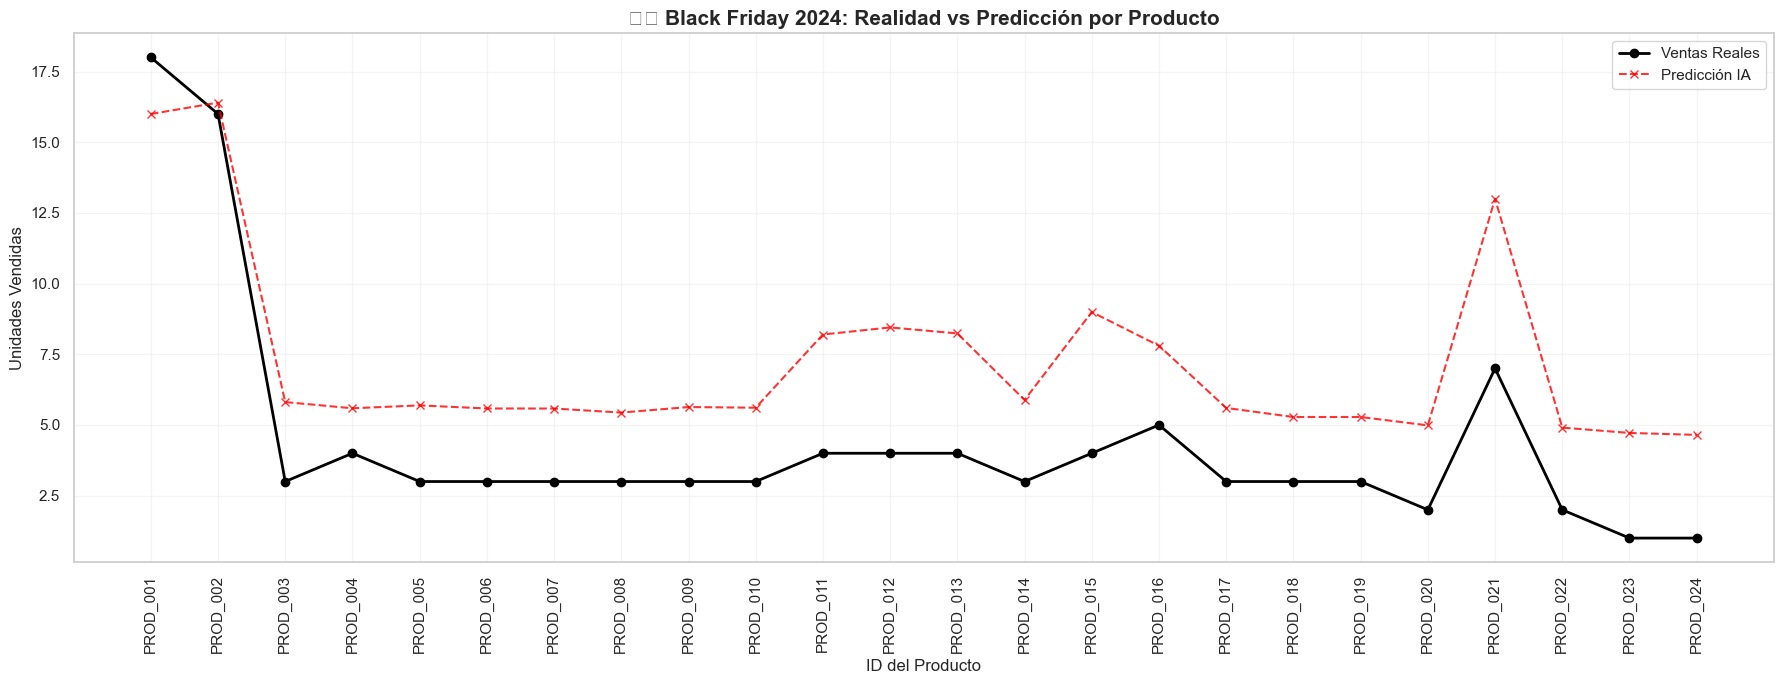

📊 MAE Global del Black Friday: 3.01 unidades.


In [59]:
# 1. Filtramos los datos del Black Friday 2024
bf_2024 = DF[(DF['es_black_friday'] == True) & (DF['anio'] == 2024)].copy()

if len(bf_2024) == 0:
    print("⚠️ ¡Ojo! No hay registros marcados como Black Friday para 2024. Revisemos la fecha.")
else:
    # 2. Generamos predicciones para todos los productos en ese día
    X_bf = bf_2024[predictoras]
    bf_2024['prediccion'] = model.predict(X_bf)
    
    # Ordenamos por producto_id para que el eje X sea legible
    bf_2024 = bf_2024.sort_values('producto_id')

    # 3. Visualización: Real vs Predicción por Producto
    plt.figure(figsize=(18, 7))
    
    # Línea Realidad
    plt.plot(bf_2024['producto_id'], bf_2024['unidades_vendidas'], 
             label='Ventas Reales', color='black', marker='o', linewidth=2)
    
    # Línea Predicción
    plt.plot(bf_2024['producto_id'], bf_2024['prediccion'], 
             label='Predicción IA', color='red', marker='x', linestyle='--', alpha=0.8)

    # Estética del gráfico
    plt.title('⚔️ Black Friday 2024: Realidad vs Predicción por Producto', fontsize=15, fontweight='bold')
    plt.xlabel('ID del Producto')
    plt.ylabel('Unidades Vendidas')
    plt.xticks(rotation=90)
    plt.legend()
    plt.grid(True, alpha=0.2)
    
    plt.tight_layout()
    plt.show()

    # 4. Cálculo de error específico para ese día
    mae_bf = mean_absolute_error(bf_2024['unidades_vendidas'], bf_2024['prediccion'])
    print(f"📊 MAE Global del Black Friday: {mae_bf:.2f} unidades.")


In [60]:
import joblib

# 1. Usamos todo el DataFrame para el entrenamiento final
X_final = DF[predictoras]
y_final = DF[target]

print(f"🤖 Re-entrenando modelo final con {len(X_final)} registros...")

# 2. Definimos el modelo final con los mismos parámetros óptimos
final_model = HistGradientBoostingRegressor(
    learning_rate=0.01,
    max_iter=1000,
    max_depth=5,
    l2_regularization=0.1,
    random_state=42
)

# 3. Ajustamos el modelo al 100% de los datos
final_model.fit(X_final, y_final)

# 4. Guardamos el modelo en un archivo para usarlo en la APP de Streamlit
path_modelo = "../models/modelo_final_forecasting.joblib"
joblib.dump(final_model, path_modelo)

print("="*50)
print(f"✅ ¡MODELO FINAL ENTRENADO Y GUARDADO!")
print(f"📁 Ubicación: {path_modelo}")
print("="*50)


🤖 Re-entrenando modelo final con 2880 registros...
✅ ¡MODELO FINAL ENTRENADO Y GUARDADO!
📁 Ubicación: ../models/modelo_final_forecasting.joblib


🤖 Calculando la importancia de las variables (esto puede tardar un poco)...


C:\Users\Pedro\AppData\Local\Temp\ipykernel_18856\1645541432.py:21: UserWarning: Glyph 127942 (\N{TROPHY}) missing from font(s) Arial.
  plt.tight_layout()
c:\Users\Pedro\miniconda3\envs\Forecasting\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 127942 (\N{TROPHY}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


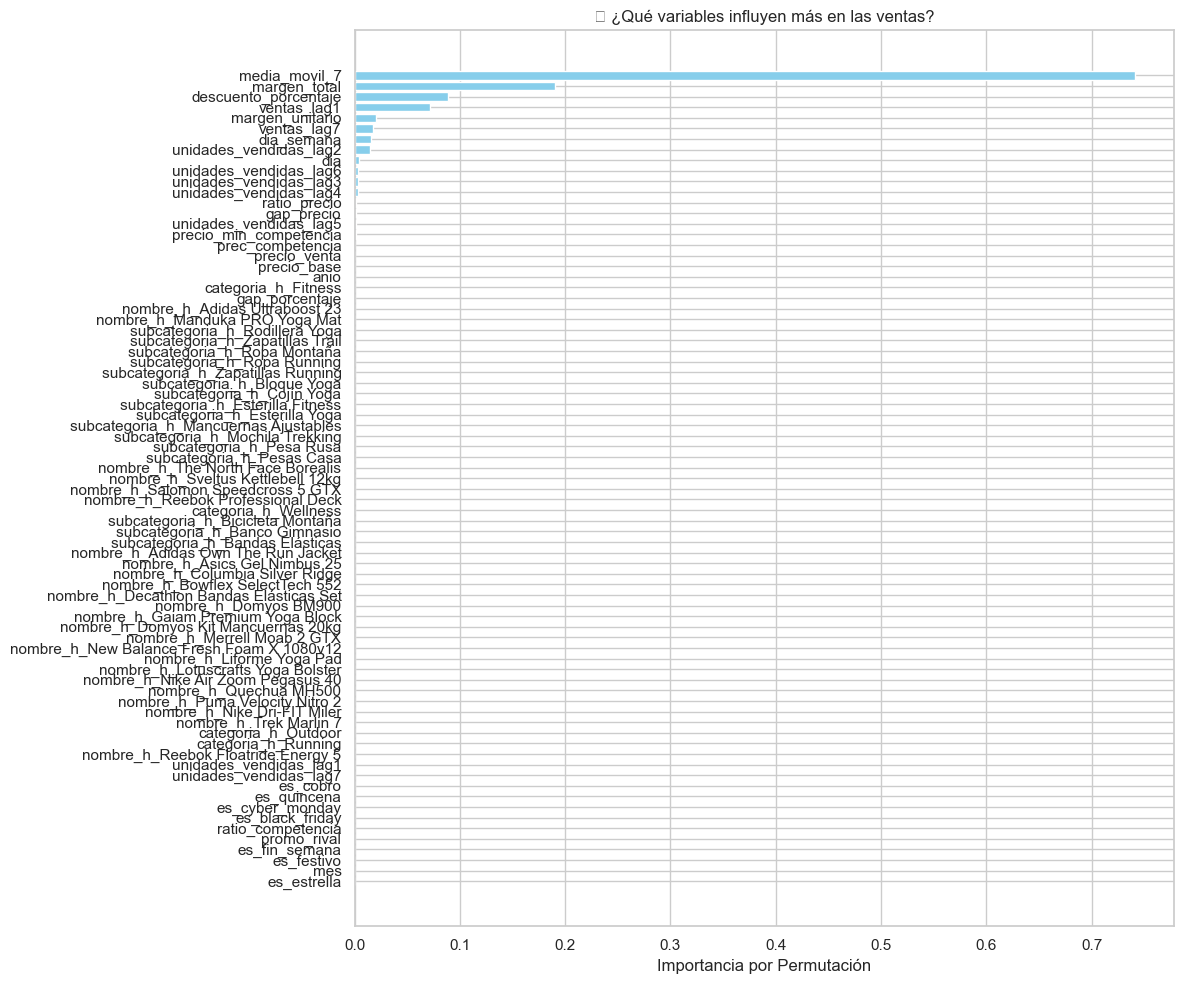

✅ ¡Modelo guardado con éxito en: ../models/modelo_final_forecasting.joblib!

--- TOP 5 VARIABLES MÁS INFLUYENTES ---
                Variable  Importancia
76         media_movil_7     0.741278
75          margen_total     0.189833
74  descuento_porcentaje     0.089016
73           ventas_lag1     0.071791
72       margen_unitario     0.019994


In [61]:
from sklearn.inspection import permutation_importance
import joblib

# 1. Calculamos la importancia mediante permutación
# (Este proceso puede tardar unos segundos porque 'baraja' los datos para ver cuánto importa cada columna)
print("🤖 Calculando la importancia de las variables (esto puede tardar un poco)...")
perm_importance = permutation_importance(final_model, X_final, y_final, n_repeats=10, random_state=42)

# 2. Preparamos los datos para el gráfico
sorted_idx = perm_importance.importances_mean.argsort()
df_importancia = pd.DataFrame({
    'Variable': np.array(predictoras)[sorted_idx],
    'Importancia': perm_importance.importances_mean[sorted_idx]
})

# 3. Graficamos (Barras horizontales de mayor a menor)
plt.figure(figsize=(12, 10))
plt.barh(df_importancia['Variable'], df_importancia['Importancia'], color='skyblue')
plt.xlabel("Importancia por Permutación")
plt.title("🏆 ¿Qué variables influyen más en las ventas?")
plt.tight_layout()
plt.show()

# 4. Guardamos el modelo en la carpeta 'models'
path_modelo = "../models/modelo_final_forecasting.joblib"
joblib.dump(final_model, path_modelo)

print(f"✅ ¡Modelo guardado con éxito en: {path_modelo}!")
print("\n--- TOP 5 VARIABLES MÁS INFLUYENTES ---")
print(df_importancia.sort_values('Importancia', ascending=False).head(5))
